In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# show plots inside notebook
%matplotlib inline

In [2]:
file_path = r"C:\Users\Admin\Downloads\database.csv.zip"

df = pd.read_csv(file_path, compression='zip')

# check first rows
df.head()

,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program
0,DR-1,Disaster,05/02/1953,GA,NaN,Tornado,Tornado,05/02/1953,05/02/1953,06/01/1954,Yes,No,Yes,Yes
1,DR-2,Disaster,05/15/1953,TX,NaN,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01/01/1958,Yes,No,Yes,Yes
2,DR-3,Disaster,05/29/1953,LA,NaN,Flood,Flood,05/29/1953,05/29/1953,02/01/1960,Yes,No,Yes,Yes
3,DR-4,Disaster,06/02/1953,MI,NaN,Tornado,Tornado,06/02/1953,06/02/1953,02/01/1956,Yes,No,Yes,Yes
4,DR-5,Disaster,06/06/1953,MT,NaN,Flood,Floods,06/06/1953,06/06/1953,12/01/1955,Yes,No,Yes,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46185 entries, 0 to 46184
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Declaration Number                46185 non-null  object
 1   Declaration Type                  46185 non-null  object
 2   Declaration Date                  46185 non-null  object
 3   State                             46185 non-null  object
 4   County                            45988 non-null  object
 5   Disaster Type                     46185 non-null  object
 6   Disaster Title                    46185 non-null  object
 7   Start Date                        46185 non-null  object
 8   End Date                          45843 non-null  object
 9   Close Date                        35210 non-null  object
 10  Individual Assistance Program     46185 non-null  object
 11  Individuals & Households Program  46185 non-null  object
 12  Public Assistance 

In [4]:
df.isnull().sum()

Declaration Number                      0
Declaration Type                        0
Declaration Date                        0
State                                   0
County                                197
Disaster Type                           0
Disaster Title                          0
Start Date                              0
End Date                              342
Close Date                          10975
Individual Assistance Program           0
Individuals & Households Program        0
Public Assistance Program               0
Hazard Mitigation Program               0
dtype: int64

In [5]:
# remove extra spaces just in case
df.columns = df.columns.str.strip()

# convert date columns
df['Declaration Date'] = pd.to_datetime(df['Declaration Date'], errors='coerce')
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')
df['End Date'] = pd.to_datetime(df['End Date'], errors='coerce')


In [6]:
df['Year'] = df['Declaration Date'].dt.year
df['Month'] = df['Declaration Date'].dt.month

df['Duration'] = (df['End Date'] - df['Start Date']).dt.days

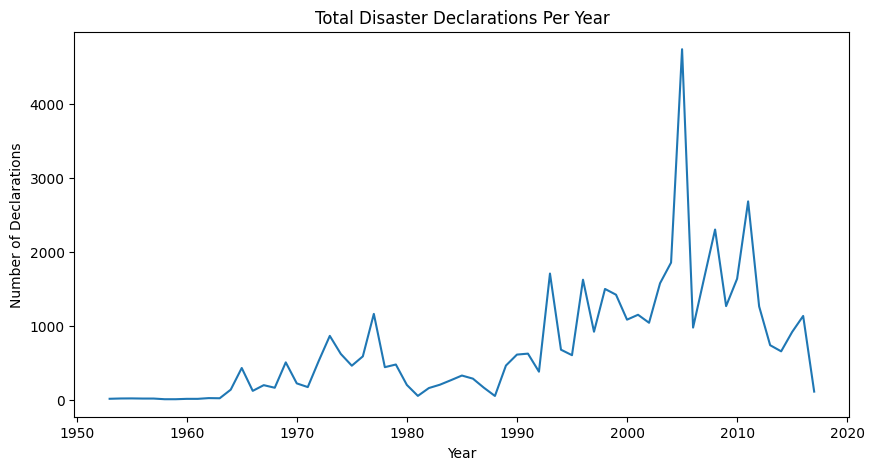

In [7]:
year_data = df.groupby('Year').size()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(year_data.index, year_data.values)
plt.title("Total Disaster Declarations Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Declarations")
plt.show()

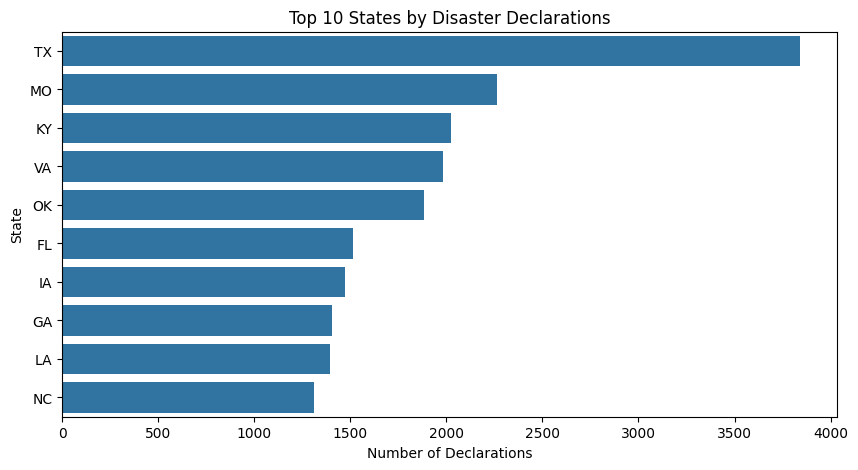

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

state_data = df['State'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=state_data.values, y=state_data.index)
plt.title("Top 10 States by Disaster Declarations")
plt.xlabel("Number of Declarations")
plt.ylabel("State")
plt.show()